# Closed-Loop Linear Model Predictive Control

This notebook demonstrates a closed-loop Model Predictive Control (MPC) simulation for a simple unstable linear 2D system using the `OCP` class.

In [1]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt

from model_predictive_control.ocp import OCP, linear_dynamics, quadratic_objective, terminal_quadratic_objective, state_bounds_constraints, control_bounds_constraints
from model_predictive_control.plots import plot_states, plot_controls, plot_mpc_trajectories

## 1. Linear System Dynamics

We define a generic unstable linear system $x_{k+1} = A x_k + B u_k$.

In [2]:
A = np.array([[1.0, 0.1], 
              [0.5, 1.0]]) 
B = np.array([[0.0], 
              [0.1]])

nx = A.shape[1]
nu = B.shape[1]

# Create discrete dynamics function
dynamics = linear_dynamics(A, B)

## 2. Objective Function and Constraints

We use a standard quadratic objective to penalize state deviations and control effort, and box constraints for safety.

In [3]:
# Objective matrices
Q = np.diag([10.0, 1.0])
R = np.array([[1.0]])

q_term = np.zeros(nx)
r_term = np.zeros(nu)
N_cross = np.zeros((nx, nu))

objective = quadratic_objective(Q, R, q_term, r_term, N_cross)

# Terminal objective
Qf = Q * 10.0
terminal_objective = terminal_quadratic_objective(Qf, q_term)

# Constraints
u_max_val = 5.0
u_min = np.array([-u_max_val])
u_max = np.array([u_max_val])

x_max_val = 2.0
x_min = np.array([-x_max_val, -x_max_val])
x_max = np.array([x_max_val, x_max_val])

state_bounds = state_bounds_constraints(x_min, x_max, nu)
control_bounds = control_bounds_constraints(u_min, u_max, nx)

x = ca.MX.sym('x', nx)
u = ca.MX.sym('u', nu)

in_eq_constraints = ca.Function('in_eq', [x, u], [ca.vertcat(state_bounds(x, u), control_bounds(x, u))])

## 3. OCP Setup and Closed-Loop Simulation

In [4]:
N_horizon = 10
N_sim = 40
dt = 0.1

ocp = OCP(
    N=N_horizon,
    dt=dt,
    objective=objective,
    dynamics=dynamics,
    terminal_objective=terminal_objective,
    in_eq_constraints=in_eq_constraints
)

# Setup using multiple shooting and ipopt
ocp.setup(
    method="multiple_shooting",
    dynamics_type="discrete",
    solver="ipopt",
    solver_opts={"print_level": 0}
)

# Simulation loop
x0_val = np.array([1.5, 0.0]) # Start near the bound
X_closed_loop = np.zeros((nx, N_sim + 1))
U_closed_loop = np.zeros((nu, N_sim))
X_open_loop = np.zeros((N_sim, nx, N_horizon + 1))

X_closed_loop[:, 0] = x0_val
current_x = x0_val

for k in range(N_sim):
    X_opt, U_opt, status = ocp.solve(current_x)
    
    # Extract first control action
    u_k = U_opt[:, 0]
    
    # Store predictions for plotting
    X_open_loop[k, :, :] = X_opt
    
    # Apply control to system
    x_next = A @ current_x + B @ u_k
    
    # Store results
    U_closed_loop[:, k] = u_k
    X_closed_loop[:, k+1] = x_next
    
    # Update current state
    current_x = x_next

print("Simulation finished.")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 192.00us (  8.00us)  55.90us (  2.33us)        24
       nlp_g  | 364.00us ( 15.17us) 115.19us (  4.80us)        24
  nlp_grad_f  | 270.00us ( 18.00us)  89.27us (  5.95us)        15
  nlp_hess_l  | 127.00us (  7.47us)  57.32us (  3.37us)        17
   nlp_jac_g  | 199.00us (  9.48us)  72.47us (  3.45us)        21
       total  | 106.55ms (106.55ms)  37.81ms ( 37.81ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 202.00us (  7.77us) 137.02us (  5.27us)        26
       nlp_g  | 339

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  74.00us (  2.74us)  67.43us (  2.50us)        27
       nlp_g  | 185.00us (  6.85us) 132.61us (  4.91us)        27
  nlp_grad_f  |  38.00us (  2.71us)  36.39us (  2.60us)        14
  nlp_hess_l  |  63.00us (  3.00us)  54.63us (  2.60us)        21
   nlp_jac_g  |  93.00us (  3.72us)  92.43us (  3.70us)        25
       total  |  29.34ms ( 29.34ms)  28.86ms ( 28.86ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  79.00us (  2.72us)  74.03us (  2.55us)        29
       nlp_g  | 192.00us (  6.62us) 177.45us (  6.12us)        29
  nlp_grad_f  |  38.00us (  2.71us)  35.97us (  2.57us)        14
  nlp_hess_l  |  64.00us (  3.05us)  58.18us (  2.77us)        21
   nlp_jac_g  |  85.00us (  3.40us)  85.38us (  3.42us)        25
       total  |  29.63ms ( 29.63ms)  29.62ms ( 29.62ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  67.00us (  2.91us)  69.98us (  3.04us)        23
       nlp_g  | 176.00us (  7.65us) 137.66us (  5.99us)        23
  nlp_grad_f  |  39.00us (  3.00us)  35.14us (  2.70us)        13
  nlp_hess_l  |  75.00us (  3.95us)  70.76us (  3.72us)        19
   nlp_jac_g  |  76.00us (  3.30us)  76.38us (  3.32us)        23
       total  |  27.03ms ( 27.03ms)  26.58ms ( 26.58ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  57.00us (  2.48us)  54.79us (  2.38us)        23
       nlp_g  | 156.00us (  6.78us) 117.74us (  5.12us)        23
  nlp_grad_f  |  35.00us (  2.69us)  35.55us (  2.73us)        13
  nlp_hess_l  |  53.00us (  2.79us)  46.41us (  2.44us)        19
   nlp_jac_g  |  79.00us (  3.43us)  75.30us (  3.27us)        23
       total  |  24.71ms ( 24.71ms)  24.71ms ( 24.71ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  76.00us (  3.30us)  66.09us (  2.87us)        23
       nlp_g  | 172.00us (  7.48us) 134.45us (  5.85us)        23
  nlp_grad_f  |  57.00us (  4.38us)  54.38us (  4.18us)        13
  nlp_hess_l  |  62.00us (  3.26us)  54.03us (  2.84us)        19
   nlp_jac_g  |  90.00us (  3.91us)  81.64us (  3.55us)        23
       total  |  30.11ms ( 30.11ms)  29.46ms ( 29.46ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  61.00us (  2.44us)  56.72us (  2.27us)        25
       nlp_g  | 177.00us (  7.08us) 134.55us (  5.38us)        25
  nlp_grad_f  |  38.00us (  2.92us)  36.53us (  2.81us)        13
  nlp_hess_l  |  59.00us (  2.81us)  56.05us (  2.67us)        21
   nlp_jac_g  |  83.00us (  3.32us)  80.73us (  3.23us)        25
       total  |  30.21ms ( 30.21ms)  30.20ms ( 30.20ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  83.00us (  2.96us)  76.49us (  2.73us)        28
       nlp_g  | 182.00us (  6.50us) 136.98us (  4.89us)        28
  nlp_grad_f  |  36.00us (  2.77us)  35.46us (  2.73us)        13
  nlp_hess_l  |  62.00us (  2.82us)  95.47us (  4.34us)        22
   nlp_jac_g  |  89.00us (  3.42us)  87.28us (  3.36us)        26
       total  |  29.31ms ( 29.31ms)  28.39ms ( 28.39ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  85.00us (  2.83us)  72.08us (  2.40us)        30
       nlp_g  | 196.00us (  6.53us) 147.56us (  4.92us)        30
  nlp_grad_f  |  35.00us (  2.69us)  34.63us (  2.66us)        13
  nlp_hess_l  |  60.00us (  2.50us)  57.38us (  2.39us)        24
   nlp_jac_g  | 100.00us (  3.57us)  93.02us (  3.32us)        28
       total  |  30.43ms ( 30.43ms)  30.43ms ( 30.43ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 108.00us (  3.09us)  91.97us (  2.63us)        35
       nlp_g  | 322.00us (  9.20us) 217.12us (  6.20us)        35
  nlp_grad_f  |  45.00us (  3.21us)  40.13us (  2.87us)        14
  nlp_hess_l  |  81.00us (  2.89us)  73.59us (  2.63us)        28
   nlp_jac_g  | 138.00us (  4.31us) 111.01us (  3.47us)        32
       total  |  36.88ms ( 36.88ms)  35.79ms ( 35.79ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 175.00us (  3.80us) 110.87us (  2.41us)        46
       nlp_g  | 259.00us (  5.63us) 217.67us (  4.73us)        46
  nlp_grad_f  |  43.00us (  2.87us)  42.34us (  2.82us)        15
  nlp_hess_l  |  73.00us (  2.81us)  64.37us (  2.48us)        26
   nlp_jac_g  | 101.00us (  3.37us) 100.62us (  3.35us)        30
       total  |  33.54ms ( 33.54ms)  33.54ms ( 33.54ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp

## 4. Plot Results

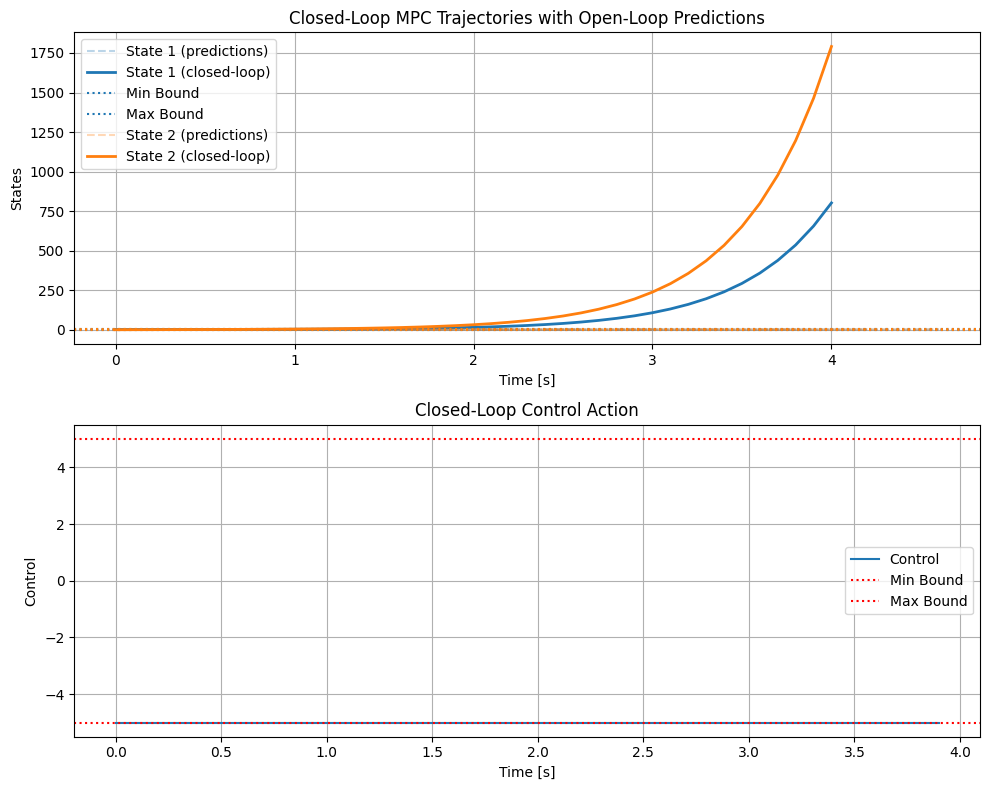

In [5]:
time = np.arange(N_sim + 1) * dt

fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Plot states with open loop predictions
plot_mpc_trajectories(
    time, 
    X_closed_loop, 
    X_open_loop, 
    labels=['State 1', 'State 2'], 
    fig=fig, 
    ax=axs[0], 
    title='Closed-Loop MPC Trajectories with Open-Loop Predictions',
    bounds=[(x_min[0], x_max[0]), (x_min[1], x_max[1])],
    step_interval=4
)

# Plot controls
plot_controls(
    time, 
    U_closed_loop, 
    labels=['Control'], 
    fig=fig, 
    ax=axs[1], 
    title='Closed-Loop Control Action',
    bounds=[(u_min[0], u_max[0])]
)

plt.tight_layout()
plt.show()